In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Why is long DFT/FFT not always good?
Students have learnt that the frequency resolution $\Delta f$ depends on the DFT length $N$. That is,
\\[
\Delta f = \frac{f_{s}}{N}.
\\]
Where $N$ is the length of the time windowed signal in the DFT. This could lead to a naive conclusion that the longer the length, the better DFT result. This is not always the case. This section will guide you through the reason behind this.

## Learning Objectives
After completing this notebook, you should be able to:
* distinguish between deterministic and random signals;
* explain the meaning of repeated experiments and realizations;
* identify signal properties that remain statistically similar across realizations;
* explain why the FFT of a random signal varies from one record to another;
* distinguish fine frequency-bin spacing from a stable spectral estimate;
* explain why random signals require statistical spectral descriptions such as PSD.

## Structure of presentation
1. Deterministic and random signals
2. From time-domain variability to spectral variability
3. White noise does not produce a flat DFT!
4. Longer records: Finer grid, but random spectras still vary
5. Real measurements: Signal plus noise
6. Why statistical spectral descriptions are needed

## 1. Deterministic and Random Signals
### 1.1 Repeating a Signal-Generation Experiment
Suppose we perform two experiments:
1. Generate a sinusoidal signal with specified parameters.
2. Generate a noise signal using a random-number generator.
Before running the following code, consider these questions:
* Will the sinusoidal waveform change when the experiment is repeated?
* Will the noise waveform change?
* If the noise changes, will it still have a similar overall appearance?

In [46]:
def plotSine_and_Noise():
    fs = 1000          # Sampling rate in Hz
    duration = 0.2     # Signal duration in seconds
    N = int(fs * duration)
    t = np.arange(N) / fs

    A = 1.0
    f1 = 20.0
    phi = 0.0
    x_sine = A*np.sin((2*np.pi*f1*t) + phi)
    # np.random.randn(N) generates gaussian random vector of length N with mean=0, and variance=1.
    x_noise = np.random.randn(N) 

    fig,ax = plt.subplots(2,1,figsize=(10,4),sharex=True)
    ax[0].plot(t,x_sine)
    ax[0].set_title("Sinusoidal signal")
    ax[0].set_ylabel("Amplitude")
    ax[0].grid()

    ax[1].plot(t,x_noise)
    ax[1].set_title("Noise")
    ax[1].set_ylabel("Amplitude")
    ax[1].set_xlabel("Time (s)")
    ax[1].grid()

    plt.tight_layout()
    return None

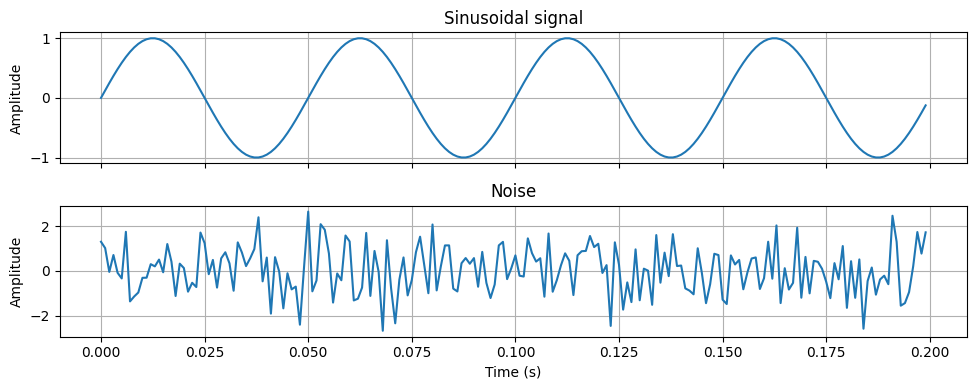

In [47]:
plotSine_and_Noise()

### Observation Questions
1. Does the sinusoidal waveform change?
2. Does the noise waveform change?
3. Can the next sample of the sinusoid be predicted?
4. Can the next sample of the noise be predicted exactly?
5. Although the noise waveform changes, does it still look like the same general kind of signal?

## 1.2 Deterministic Signals
A **deterministic signal** is a signal whose values are completely specified by a mathematical rule and its parameters. For example, a sampled sinusoidal signal can be written as

\\[
x[n] = A\sin\left(2\pi f_1\frac{n}{f_s}+\phi\right),
\\]

where:
* ($A$) is the amplitude;
* ($f_1$) is the sinusoidal frequency;
* ($f_s$) is the sampling rate;
* ($\phi$) is the initial phase;
* ($n$) is the sample index.

When these parameters remain unchanged, the signal will be reproduced exactly.

**Key idea:** A deterministic signal can be reproduced exactly when its rule and parameters are unchanged.
**Caution!** A deterministic signal does not have to be a simple sinusoid.

## 1.3 Random signals
A **random signal** cannot be predicted exactly sample by sample before it is generated or measured. We can see this by generating several noise records using the same instruction.

In [6]:
# Try to run this serveral time, look at the statistics and the plots you may notice something.
fs = 1000          # Sampling rate in Hz
duration = 0.2     # Signal duration in seconds
N = int(fs * duration)
t = np.arange(N) / fs

fig, ax = plt.subplots(1,1,figsize=(10,4))
for i in range(3):
    noise = np.random.randn(N)
    ax.plot(t,noise,label='Take #'+str(i+1))
    mean = np.mean(noise)
    var = np.var(noise)
    print('Realization #',i+1,' Mean = ', mean,' variance = ',var)
ax.grid()
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Noise with different realizations')
ax.set_xlim(0,0.2)
ax.set_ylim(-4,4)
ax.grid(True)
ax.legend(loc='upper right')
fig.tight_layout()
plt.close(fig)

Realization # 1  Mean =  0.017488314829531736  variance =  1.025594061990805
Realization # 2  Mean =  -0.13884418062625165  variance =  0.9663421370942612
Realization # 3  Mean =  -0.023114380773455158  variance =  1.0434159793769624


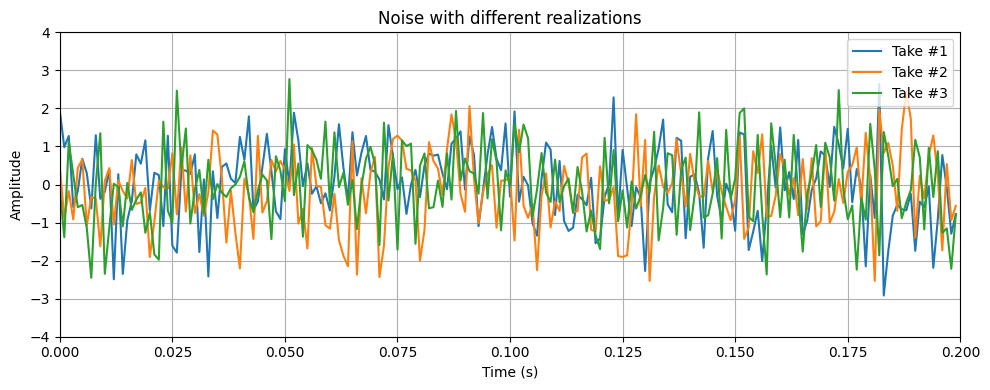

In [7]:
display(fig)

These records are different because each experiment produces a new sequence of random sample values. However, these signals still appear to have similar general behavior:
* all fluctuate around zero;
* all have similar amplitude ranges;
* all appear irregular;
* neither has an obvious repeating pattern.

**Key idea:** Repeating a random experiment produces a different waveform, even when the experiment is performed in the same way. Each run is called a *realization*. The same random process could produce different realizations. 

Random does not mean arbitrary. Though individual samples are unpredictable, but their statistical behavior is constrained by the underlying random process.

This leads to an important distinction:
* individual sample values may be unpredictable;
* overall properties of the signal may still be measurable and these properties are somewhat similar.

Examples of such properties include:
* average value;
* RMS value;
* signal power;
* amplitude distribution;
* spectral characteristics.

These properties will be examined in later sections.

### 1.4 Summary
**A deterministic signal** is completely specified by a mathematical rule and its parameters. When the same deterministic experiment is repeated, the same waveform is produced.

**A random signal** produces different sample values when an experiment is repeated. Its individual values cannot be predicted exactly in advance.

However, randomness does not imply the absence of structure. Random signals can still have measurable properties that remain similar across repeated observations.

| Deterministic signal             | Random signal                             |
| -------------------------------- | ----------------------------------------- |
| Reproduced exactly when repeated | Produces a new waveform when repeated     |
| Sample values are predictable    | Exact sample values are unpredictable     |
| Can be simple or complicated     | Can have constrained statistical behavior |
| Described by a known rule        | Described using statistical properties    |
| Example: generated sinusoid      | Example: measurement noise                |

## 2. From Time-Domain Variability to Spectral Variability
In the previous section, repeated calls to `np.random.randn()` produced different noise records. Each generated record is one **realization** of the same random process. Although the records were generated using the same rule, their sample values were different.

This section examines what happens when those different time-domain records are transformed into the frequency domain.

## 2.1 Several Realizations of the Same Noise Process

Generate several noise records using the same parameters.

In [48]:
fs = 8000
duration = 1
N = int(fs * duration)
t = np.arange(N) / fs

num_records = 5
noise_records = [np.random.randn(N) for _ in range(num_records)]
fig, ax = plt.subplots(num_records,1,figsize=(10,4),sharex=True,sharey=True)
for i, x in enumerate(noise_records):
    ax[i].plot(t[0:int(0.02*N)],x[0:int(0.02*N)])
    ax[i].set_ylabel(f"$x_{i+1}[n]$")
    ax[i].grid()
ax[-1].set_xlabel("Time (s)")
ax[0].set_title("Different realization of the same noise process")
fig.tight_layout()
plt.close(fig)

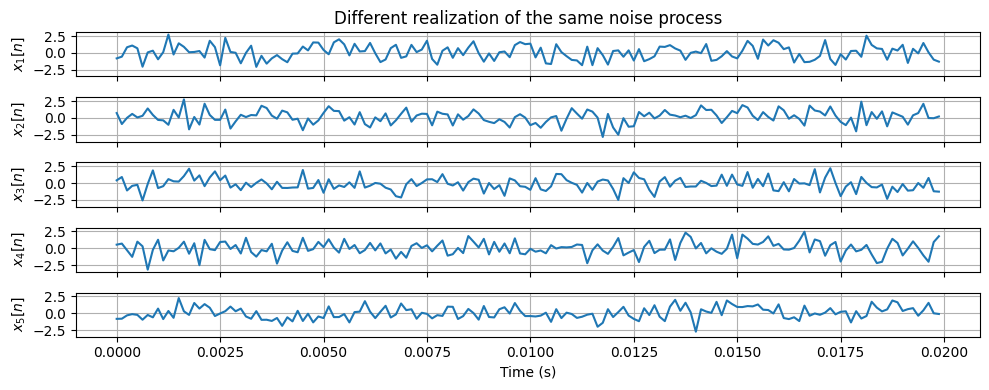

In [49]:
display(fig)

#### Observation
The records are visibly different. However, they were generated using:
* the same sampling rate;
* the same duration;
* the same random-noise model;
* approximately the same mean and variance.

We therefore treat them as different realizations of the same random process.

### 2.2 Comparing Their FFTs
For each realization, compute a windowed FFT. A Hann window is used to reduce finite-record edge effects.

In [52]:
window = np.hanning(N)
frequency = np.fft.rfftfreq(N, d=1/fs)
spectra = []
for x in noise_records:
    X = np.fft.rfft(x * window)
    Xm = np.abs(X)
    spectra.append(Xm)
fig, ax = plt.subplots(1,1,figsize=(10, 4))
for i, Xm in enumerate(spectra):
    ax.plot(frequency,20*np.log10(Xm + 1e-12),label=f"Record {i+1}",alpha=0.75)
#plt.ylim((0,60))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude DFT (dB)")
ax.set_title("Magnitude DFT of Different Noise Realizations")
ax.grid()
ax.legend()
plt.close(fig)

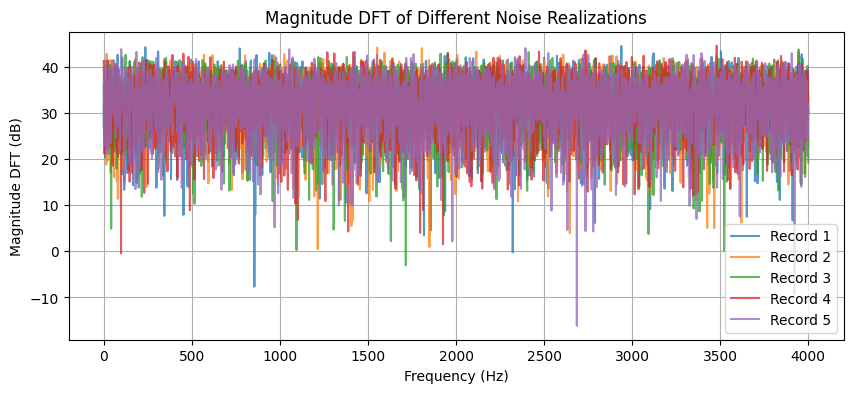

In [53]:
display(fig)

Before running the cell again, consider the following question:
* If all records come from the same random process, should their FFT spectra be identical?

Let's run the noise-generation and plotting cells several times.

## 2.3 The Spectrum Changes with the Realization
Let the noise realizations be written as

\\[
x_1[n],\quad x_2[n],\quad \ldots,\quad x_R[n].
\\]

Their DFTs are

\\[
X_r[k] = \sum_{n=0}^{N-1}x_r[n]e^{-j2\pi kn/N}
\\]

where ($r$) identifies the realization.

Because the time-domain records are different,

\\[
x_1[n] \neq x_2[n],
\\]

their spectra are also generally different:

\\[
|X_1[k]|^2 \neq |X_2[k]|^2.
\\]

This does not mean that the FFT has failed. The FFT is correctly describing the particular finite record that was supplied to it.

The important point is that a single FFT describes only one realization. It does not provide a unique, unchanging spectrum for the entire random process.

**Key idea:** Different realizations of the same random process generally produce different FFT spectra.

## 2.4 Examining One Frequency Bin
The variability can also be seen by examining one frequency bin across many realizations. Generate many noise records and record the signal power at one selected frequency bin.

In [16]:
num_realizations = 200
selected_frequency = 1000

selected_bin = np.argmin(np.abs(frequency - selected_frequency))

bin_power = []

for _ in range(num_realizations):
    x = np.random.randn(N)
    X = np.fft.rfft(x * window)
    # The following calculates the power of the signal at different bins
    # You will learn this with in a few weeks.
    P = 2 * (np.abs(X) ** 2) / (N*(np.sum(window**2))) 
    bin_power.append(P[selected_bin]) # Select only one bin to observe

bin_power = np.asarray(bin_power) # Signal power at the same bin for various realizations

fig,ax = plt.subplots(1,1,figsize=(10, 4))
ax.plot(bin_power, marker=".",linestyle="none")
ax.set_xlabel("Realization Number")
ax.set_ylabel("Power at Selected Bin")
ax.set_title(f"Power Variability Near " f"{frequency[selected_bin]:.1f} Hz")
ax.grid()
fig.tight_layout()
plt.close(fig)

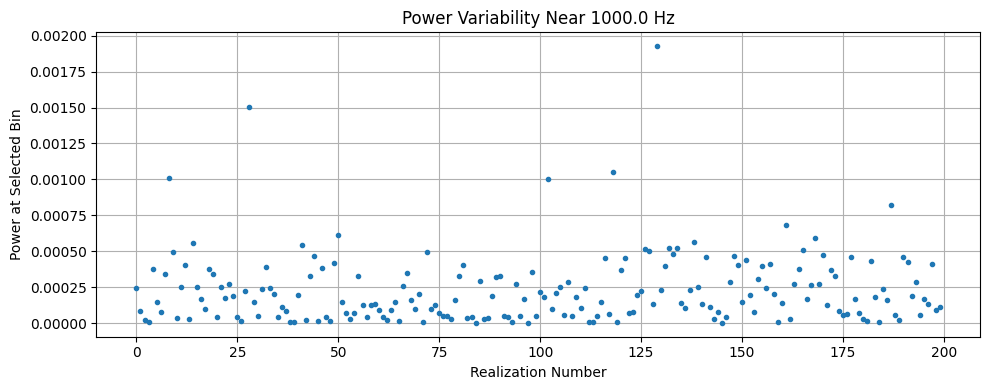

In [17]:
display(fig)

The selected frequency bin does not produce the same value in every realization. Some realizations produce a relatively large value, while others produce a relatively small value.

This occurs even though every record was generated by the same random-noise model.

### Observation Questions
1. Is the selected-bin power constant across realizations?
2. Does one unusually large value indicate a permanent spectral component?
3. Would a different set of realizations produce exactly the same sequence of values?
4. Can one realization reliably describe the typical power at this frequency?

## 2.5 A Single FFT Is Only One Observation
* For a deterministic sinusoid, a stable tone may appear at the same frequency in repeated records.
* For a random signal, however, the value observed at each spectral bin changes from one realization to another.
* Therefore, the spectrum of a random signal must be interpreted differently from the spectrum of a deterministic signal.

**A single FFT provides:**
* the frequency-domain description of one finite record;
* the spectral values observed in one realization;
* one possible outcome of the random process.

**It does not directly provide:**
* the typical spectral behavior across repeated experiments;
* the average power expected at each frequency;
* a perfectly stable spectral curve.

This variation from one record to another is called **spectral variability**.

> **Spectral variability** is the variation in spectral values caused by changing the realization or the selected data record.

The noise spectra do not lie on top of one another. This difference is a direct consequence of repeatability in the time domain:

| Signal type        | Time-domain repetition | Frequency-domain repetition |
| ------------------ | ---------------------- | --------------------------- |
| Deterministic tone | Same waveform          | Same spectrum               |
| Random noise       | Different realization  | Different spectrum          |

### 2.6 What Can Be Concluded from One FFT?
From one FFT of a random signal, we can conclude what occurred in that particular record. However, we should be careful about interpreting individual peaks or dips as permanent features of the random process.

* A large spectral value at one bin may result from random variation.
* A small spectral value at another bin may also result from random variation.

> To describe the random process itself, rather than one realization, we need a spectral quantity based on statistical behavior across records or observations.

## Review Questions
1. What is meant by a realization of a random process?
2. Why do different noise realizations produce different FFT spectra?
3. Does a different spectrum imply that the signals came from different random processes?
4. What does a single FFT describe?
5. What is spectral variability?
6. Why should isolated peaks in a single noise spectrum be interpreted carefully?

### Main Takeaway
> A single FFT of a random signal describes one realization. Different realizations produce different spectral values, even when they come from the same random process.

## 3. White Noise Does Not Produce a Flat FFT
White noise is often described as having a **flat spectrum**. However, the DFT magnitude of one white-noise record does not usually look flat. It contains many irregular peaks and dips.

This apparent contradiction occurs because a single DFT represents only one realization of the random signal.

### 3.1 The DFT of One White-Noise Record
Generate one white-noise record.

In [18]:
fs = 8000
duration = 1.0
N = int(fs * duration)

x = np.random.randn(N)
window = np.hanning(N)

X = np.fft.rfft(x * window)
frequency = np.fft.rfftfreq(N, d=1/fs)
magnitude = np.abs(X)

fig,ax = plt.subplots(1,1,figsize=(10, 4))
ax.plot(frequency, magnitude)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("DFT Magnitude")
ax.set_title("DFT Magnitude of One White-Noise Record")
ax.grid()
fig.tight_layout()
plt.close(fig)

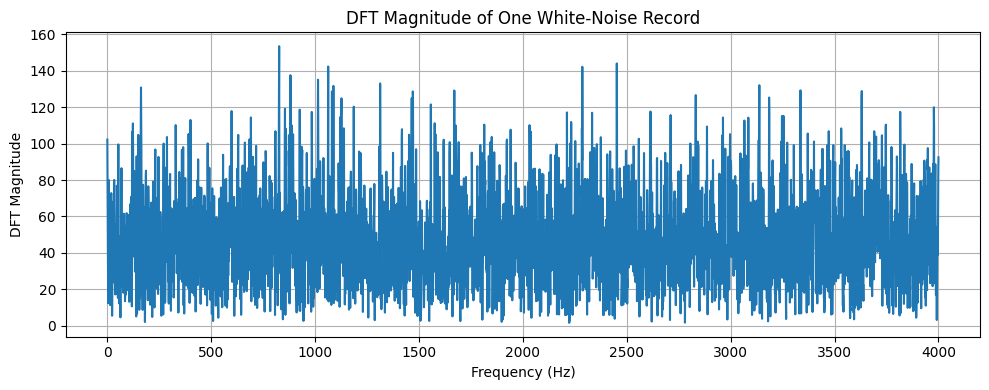

In [19]:
display(fig)

#### Observation
The curve is not flat. Some frequency bins have large magnitudes, while other bins have small magnitudes.

Run the signal-generation and plotting cells several times. Each new noise record produces a different irregular DFT magnitude.

#### Question!
> If white noise is supposed to have a flat spectrum, why does the DFT magnitude not form a horizontal line?


### 3.2 What Does “White” Mean?
The term **white noise** does not mean that every finite record contains exactly the same amount of power at every DFT bin.

Instead, it means that the random process has no preferred frequency.

Over repeated observations, **the expected power is distributed uniformly with frequency**.

Therefore, these two statements have different meanings:
> Every DFT of white noise is flat.

The above statement is false.
> The expected spectral power of white noise is constant with frequency.

The above statement describes the meaning of white noise.

The distinction is between:
* the spectral result from one realization;
* the statistical spectral behavior of the random process.

### 3.3 Squared DFT Magnitude of One Realization
In many practical applications, we are interested not only in the DFT magnitude, but in how the signal’s **power** is distributed across frequency. Since signal power is related to the squared signal amplitude, the corresponding frequency-domain quantity begins with

\\[
P[x] \propto |X[k]|^2.
\\]

The values must then be properly scaled to represent power in each DFT bin. You will learn about the scaling factor of the signal power in a few weeks.

For one realization, calculate the power contained in each one-sided DFT bin.

In [21]:
window_energy = np.sum(window**2)
bin_power = np.abs(X)**2 / (N * window_energy)

if N % 2 == 0:
    bin_power[1:-1] *= 2
else:
    bin_power[1:] *= 2

fig,ax = plt.subplots(figsize=(10, 4))
ax.plot(frequency, bin_power)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power in DFT Bin")
ax.set_title("Power Distribution of One White-Noise Record")
ax.grid()
fig.tight_layout()
plt.close(fig)

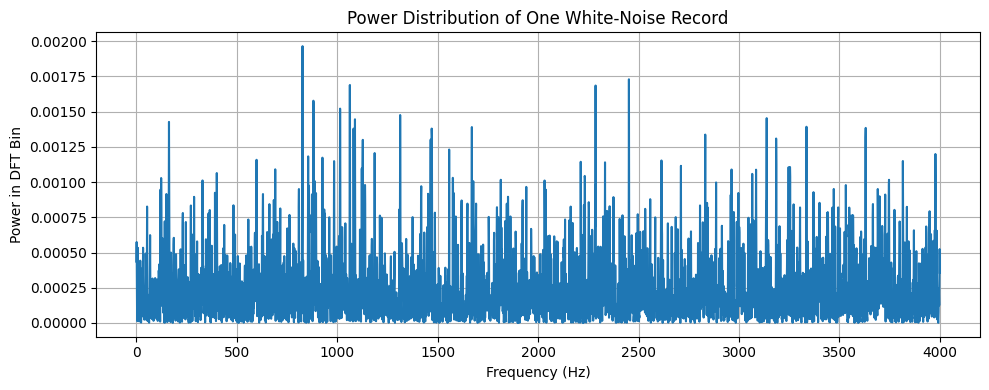

In [22]:
display(fig)

The result is still irregular. This does not mean that the noise is not white. It means that one realization contains random fluctuations in its DFT coefficients.

A large value at one bin does not necessarily represent a persistent frequency component. Similarly, a small value at another bin does not necessarily mean that the random process contains little power near that frequency.

> **Key idea:** Whiteness is not determined from the exact shape of one noisy DFT curve.

### 3.4 Repeating the Experiment
Generate several white-noise realizations and plot their bin powers.

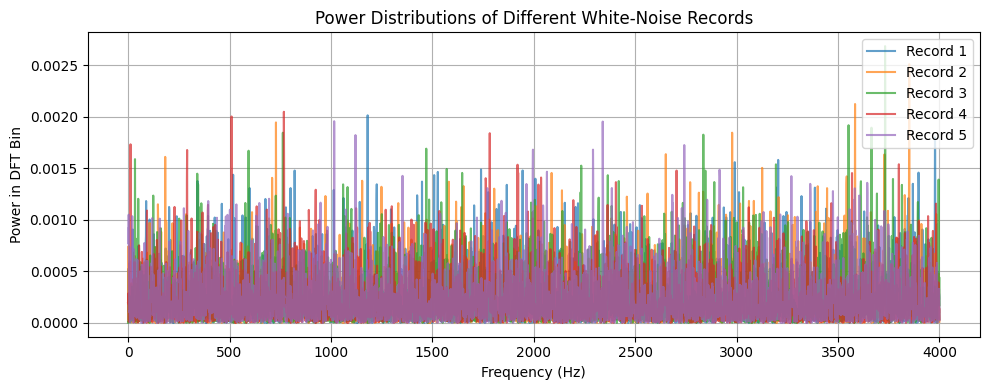

In [25]:
num_records = 5
bin_power_records = []
for _ in range(num_records):
    x = np.random.randn(N)
    X = np.fft.rfft(x * window)
    bin_power = np.abs(X)**2 / (N * window_energy)
    if N % 2 == 0:
        bin_power[1:-1] *= 2
    else:
        bin_power[1:] *= 2
    bin_power_records.append(bin_power)

fig, ax = plt.subplots(1,1,figsize=(10, 4))
for i, bin_power in enumerate(bin_power_records):
    ax.plot(frequency, bin_power, alpha=0.7, label=f"Record {i+1}")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power in DFT Bin")
ax.set_title("Power Distributions of Different White-Noise Records")
ax.grid()
ax.legend(loc='upper right')
fig.tight_layout()
plt.close(fig)

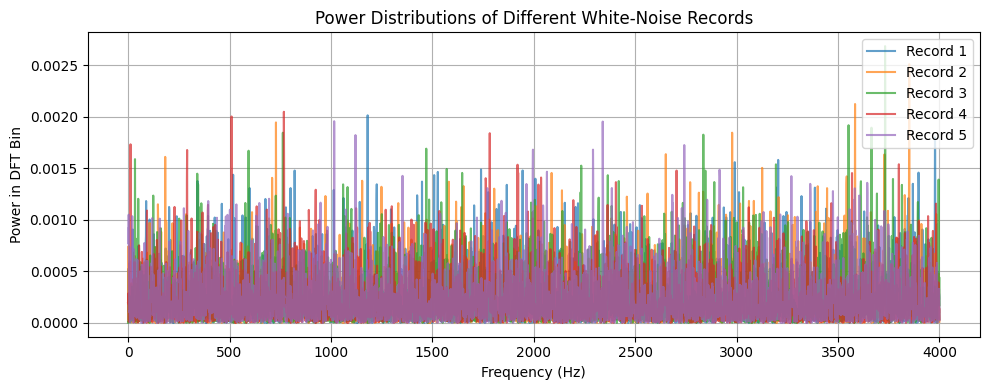

In [26]:
display(fig)

Each curve is different. Nevertheless, no frequency region remains consistently high or consistently low across all realizations.

### Observation Questions
Consider the spectrum of random noises.
1. Do the peaks occur at the same frequencies in every record?
2. Does one frequency band remain consistently dominant?
3. What happens to the curve when a new realization is generated?
4. Are the irregular peaks permanent properties of the random process?

### 3.5 Averaging Reveals the Statistical Trend
To see the underlying statistical behavior, generate many realizations and calculate the average bin power.

This is only a preview of spectral averaging. The formal methods will be introduced later.

In [27]:
num_realizations = 500
power_sum = np.zeros(N // 2 + 1)
for _ in range(num_realizations):
    x = np.random.randn(N)
    X = np.fft.rfft(x * window)
    bin_power = np.abs(X)**2 / (N * window_energy)
    if N % 2 == 0:
        bin_power[1:-1] *= 2
    else:
        bin_power[1:] *= 2
    power_sum += bin_power

average_bin_power = (power_sum / num_realizations)
x = np.random.randn(N)
X = np.fft.rfft(x * window)
single_bin_power = np.abs(X)**2 / (N * window_energy)
if N % 2 == 0:
    single_bin_power[1:-1] *= 2
else:
    single_bin_power[1:] *= 2

fig, ax = plt.subplots(2, 1,sharex=True)
ax[0].plot(frequency,single_bin_power)
ax[0].set_title("One White-Noise Realization")
ax[0].set_ylabel("Power in DFT Bin")
ax[0].grid()

ax[1].plot(frequency,average_bin_power)
ax[1].set_title(f"Average of {num_realizations} Realizations")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Average Power in DFT Bin")
ax[1].grid()

plt.tight_layout()
plt.close(fig)

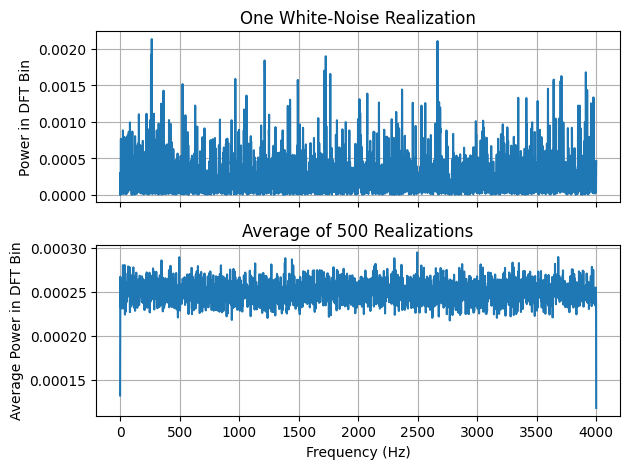

In [28]:
display(fig)

The single-realization curve is highly irregular. (Please notice that the y-axis of both graph are very much different.)

The average curve is much more uniform across frequency.

The endpoints may differ from the interior bins because DC and the Nyquist frequency do not have separate negative-frequency partners. The important observation is the approximately constant behavior across the ordinary positive-frequency bins.

> **Key idea:** The flat spectral behavior of white noise becomes visible through **statistical averaging**, not from one individual DFT.


### 3.6 More Realizations Produce a More Stable Average
Observe how the average changes as the number of realizations increases.

In [29]:
average_counts = [1,5,20,100,500]
fig, ax = plt.subplots(1,1,sharex=True,sharey=True)
for count in average_counts:
    power_sum = np.zeros(N // 2 + 1)
    for _ in range(count):
        x = np.random.randn(N)
        X = np.fft.rfft(x * window)
        bin_power = np.abs(X)**2 / (N * window_energy)
        if N % 2 == 0:
            bin_power[1:-1] *= 2
        else:
            bin_power[1:] *= 2
        power_sum += bin_power
    average_power = power_sum / count
    ax.plot(frequency,average_power,label=f"Average of {count} Realization(s)")    
ax.set_title("Average power spectrum with different number of realization.")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
ax.legend()
ax.grid()

fig.tight_layout()
plt.close(fig)

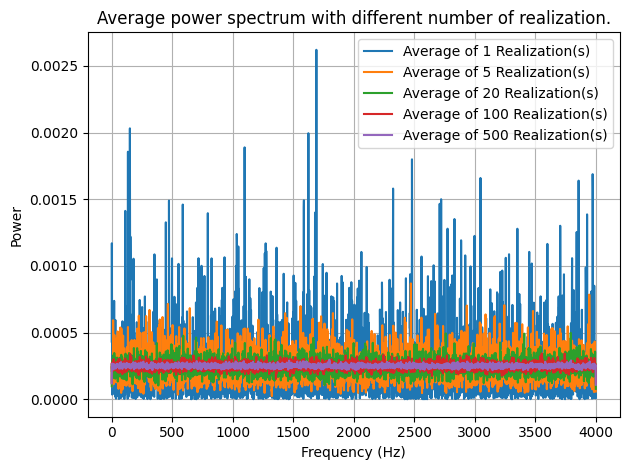

In [30]:
display(fig)

As the number of realizations increases:
* isolated peaks become less prominent;
* deep dips become less prominent;
* the average becomes more stable;
* the frequency-independent trend becomes clearer.

Averaging does not make the individual realizations less random. Instead, it reduces the influence of random fluctuations on the spectral description.

The formal interpretation and practical estimation of this average behavior will be developed in later sections.

### 3.7 Flat Does Not Mean Constant in Every Record
The word *flat* must be interpreted carefully. 
* For a deterministic signal, a repeatable spectral line may occur at the same frequency in every record.
* For white noise, individual spectral values vary randomly.

The **expected behavior** is flat, but the **observed values** in one finite record are not.

| Individual white-noise record | Statistical behavior          |
| ----------------------------- | ----------------------------- |
| Irregular DFT curve           | No preferred frequency        |
| Random peaks and dips         | Equal expected spectral level |
| Changes with realization      | Stable average trend          |
| Describes one observation     | Describes the random process  |

A single record may **accidentally contain a large peak**. That peak alone is not sufficient evidence of a sinusoidal component.

> Repeated observations or suitable averaging are needed to determine whether a feature is persistent.

## 3.8 Summary
* White noise produces a different waveform every time it is observed.
* Consequently, its DFT coefficients and bin powers also change from one realization to another.
* A single white-noise DFT is therefore irregular rather than flat.

The term *white* refers to the underlying statistical property:

> The expected spectral power is independent of frequency.

The flat trend becomes clearer when many independent realizations are considered together.

#### Review Questions
1. Why is the DFT magnitude of one white-noise record not flat?
2. What does the term *white* describe?
3. Do peaks in one white-noise DFT necessarily represent sinusoidal components?
4. Why do the peak locations change when the experiment is repeated?
5. What happens when the bin powers from many realizations are averaged?
6. Does averaging change the individual random records?
7. What is the difference between one observed DFT and the expected spectral behavior?

#### Main Takeaway

> White noise does not produce a flat DFT in every realization. Its expected spectral power is flat, while each finite record contains random spectral fluctuations.

# 4. Longer Records: Finer Bins, but Random Spectra Still Vary
For an (N)-sample record sampled at (f_s), the spacing between DFT bins is

\\[
\Delta f=\frac{f_s}{N}.
\\]

Increasing the record length gives more closely spaced frequency bins.

**However, finer frequency spacing does not guarantee that the spectral values of a random signal become stable.**

### 4.1 Power in DFT Bins and Parseval’s Theorem
The following function calculates the power assigned to each bin of a one-sided DFT.

In [33]:
def calculate_bin_power(x, window):
    N = len(x)
    X = np.fft.rfft(x * window)
    bin_power = np.abs(X)**2 / (N * np.sum(window**2))

    if N % 2 == 0:
        bin_power[1:-1] *= 2
    else:
        bin_power[1:] *= 2

    return bin_power

The sum of all bin powers is equal to the window-corrected mean-square signal value.

In [34]:
N = 8000
x = np.random.randn(N)
window = np.hanning(N)

bin_power = calculate_bin_power(x, window)

time_domain_power = np.sum((x * window)**2) / np.sum(window**2)
frequency_domain_power = np.sum(bin_power)

print(f"Time-domain power: {time_domain_power:.4f}")
print(f"Sum of bin powers: {frequency_domain_power:.4f}")

Time-domain power: 0.9924
Sum of bin powers: 0.9924


The agreement between the two values is a consequence of **Parseval’s theorem**: the DFT represents the same signal power in the frequency domain rather than creating a new quantity. After the appropriate DFT and window normalization, the sum of the powers in all DFT bins equals the mean-square power measured in the time domain.


#### Parseval’s Theorem

For a continuous-time signal and its Fourier transform,

\\[
\int_{-\infty}^{\infty}|x(t)|^2,dt=\frac{1}{2\pi}\int_{-\infty}^{\infty}|X(\omega)|^2,d\omega.
\\]

For an (N)-sample sequence and its DFT,

\\[
\sum_{n=0}^{N-1}|x[n]|^2=\frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2.
\\]

Parseval’s theorem states that the same signal energy can be calculated in either the time domain or the frequency domain. In the present calculation, it explains why the sum of the properly scaled DFT-bin powers agrees with the mean-square power calculated from the time-domain samples.


### 4.2 Noise Only: Increasing the Record Length
Generate white-noise records with several different lengths.


In [35]:
fs = 8000
record_lengths = [512, 2048, 8192, 32768]
fig, ax = plt.subplots(len(record_lengths), 1, sharex=True)
for axis, N in zip(ax, record_lengths):
    x = np.random.randn(N)
    window = np.hanning(N)
    frequency = np.fft.rfftfreq(N, d=1/fs)
    bin_power = calculate_bin_power(x, window)

    axis.plot(frequency, bin_power)
    axis.set_title(f"N = {N}, bin spacing = {fs/N:.3f} Hz")
    axis.set_ylabel("Bin Power")
    axis.grid()

ax[-1].set_xlabel("Frequency (Hz)")
fig.tight_layout()
plt.close(fig)

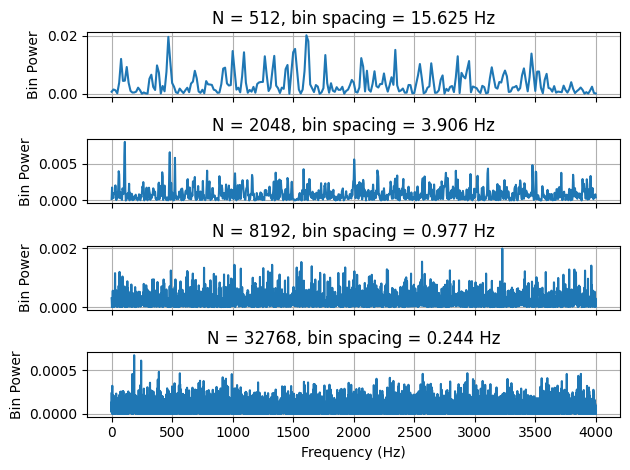

In [36]:
display(fig)

#### Observations
As (N) increases:
* the frequency bins become more closely spaced;
* the number of DFT bins increases;
* the spectral curve still contains irregular peaks and dips;
* a new realization produces a different curve.

The total signal power remains approximately the same, but it is distributed among a larger number of narrower frequency bins. Therefore, the average power contained in each bin decreases as the bin width decreases.

> Increasing (N) divides the frequency axis into smaller intervals. It does not remove the random variation between realizations.


#### Parseval’s Theorem
For a continuous-time signal and its Fourier transform,

\\[
\int_{-\infty}^{\infty}|x(t)|^2,dt = \frac{1}{2\pi}\int_{-\infty}^{\infty}|X(\omega)|^2,d\omega.
\\]

For an (N)-sample sequence and its DFT,

\\[
\sum_{n=0}^{N-1}|x[n]|^2 = \frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2.
\\]

Parseval’s theorem states that the same signal energy can be calculated in either the time domain or the frequency domain. In the present calculation, it explains why the sum of the properly scaled DFT-bin powers agrees with the mean-square power calculated from the time-domain samples.

## 4.3 Repeating the Long-Record Experiment
A long record may produce a very fine frequency grid. However, its detailed spectral pattern still depends on the particular noise realization.

Use a long record and repeat the experiment several times.

In [39]:
N = 4096
num_records = 5
window = np.hanning(N)
frequency = np.fft.rfftfreq(N, d=1/fs)
fig, ax = plt.subplots()
for i in range(num_records):
    x = np.random.randn(N)
    bin_power = calculate_bin_power(x, window)
    ax.plot(frequency, bin_power, alpha=0.7, label=f"Record {i+1}")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power in DFT Bin")
ax.set_title(f"Different Noise Realizations with N = {N}")
ax.legend()
ax.grid()
fig.tight_layout()
plt.close(fig)

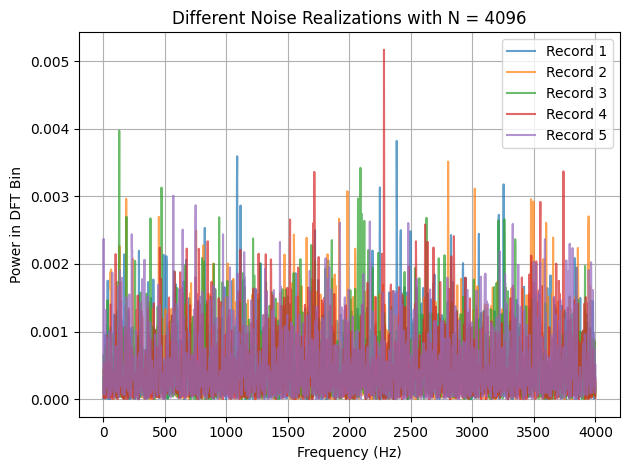

In [40]:
display(fig)

All records have the same:
* sampling rate;
* record length;
* bin spacing;
* noise-generating process.

Nevertheless, their spectral values are different.

The fine spectral detail in one curve should therefore not automatically be interpreted as a permanent property of the noise process.

> A long DFT gives a detailed description of one realization, but the random details change when the experiment is repeated.

## 4.4 Tone Only: When a Longer Record Is Useful
A longer record can provide genuinely useful frequency detail for a **deterministic signal**.

Consider two sinusoidal components with closely spaced frequencies.

In [41]:
tone_frequencies = [1000, 1020]
record_lengths = [256, 2048]
fig, ax = plt.subplots(len(record_lengths), 1, sharex=True)
for axis, N in zip(ax, record_lengths):
    t = np.arange(N) / fs
    x = np.sin(2 * np.pi * tone_frequencies[0] * t) + np.sin(2 * np.pi * tone_frequencies[1] * t)
    window = np.hanning(N)
    frequency = np.fft.rfftfreq(N, d=1/fs)
    bin_power = calculate_bin_power(x, window)

    axis.plot(frequency, bin_power,'-o')
    axis.set_xlim(900, 1120)
    axis.set_title(f"N = {N}, bin spacing = {fs/N:.2f} Hz")
    axis.set_ylabel("Bin Power")
    axis.grid()

ax[-1].set_xlabel("Frequency (Hz)")
fig.tight_layout()
plt.close(fig)

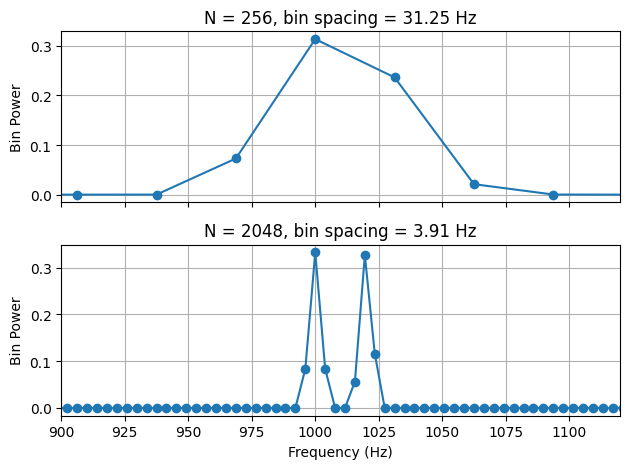

In [42]:
display(fig)

* With the shorter record, the two frequency components may not be clearly separated.
* With the longer record, the smaller bin spacing and narrower window main lobe allow the two components to be distinguished more clearly.

Thus, a longer record is useful when:

* the signal remains sufficiently stable during the record;
* closely spaced deterministic components must be separated;
* the additional frequency detail answers a meaningful question.

> A longer FFT is not inherently unnecessary. Its usefulness depends on the signal and the analysis objective.

## 4.5 Tone Plus Noise
Real measurements often contain deterministic components together with random noise. Consider

\\[
x[n]=s[n]+v[n],
\\]

where (s[n]) is a sinusoidal signal and (v[n]) is random noise.

In [44]:
N = 4096
t = np.arange(N) / fs
tone_frequency = 1000
tone = np.sin(2 * np.pi * tone_frequency * t)
window = np.hanning(N)
frequency = np.fft.rfftfreq(N, d=1/fs)

# Generate several measurements containing the same tone but different noise realizations.
fig, ax = plt.subplots()

for i in range(5):
    noise = np.random.randn(N)
    x = tone + noise
    bin_power = calculate_bin_power(x, window)
    ax.plot(frequency, 10*np.log10(bin_power), alpha=0.7, label=f"Record {i+1}")

ax.set_xlim(800, 1200)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power in DFT Bin")
ax.set_title("Repeated Measurements of the Same Tone in Noise")
ax.legend()
ax.grid()
fig.tight_layout()
plt.close(fig)

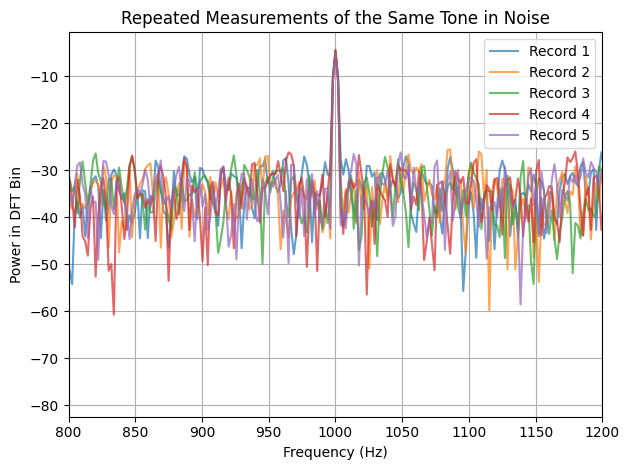

In [45]:
display(fig)

#### Observations
Across repeated measurements:
* the tone remains near the same frequency;
* the random background changes;
* the power near individual noise bins varies;
* deterministic and random components appear together in the same DFT.

#### Conclusions
* The persistent peak near the tone frequency represents repeatable information.
* The changing peaks and dips in the surrounding noise are realization-dependent.

> A long record may help reveal a stable tone, while the detailed noise background remains variable.

### 4.6 Three Different Ideas
The previous experiments illustrate three related but different concepts.

#### Frequency-Bin Spacing
\\[
\Delta f=\frac{f_s}{N}
\\]

This is the spacing between the frequencies at which the DFT is evaluated. **Increasing (N) decreases the bin spacing**.

#### Frequency Discrimination
This is the ability to distinguish closely spaced frequency components. It depends on:
* record length;
* window main-lobe width;
* the frequencies and strengths of the components.

> Zero padding could decrease the bin spacing (or ploting grid), but the frequency discrimination depends in the true signal length within the window.

#### Spectral Stability
This describes whether repeated measurements produce similar spectral values.

For a random signal, finer bins do not necessarily make the values at individual bins more repeatable.

| Increasing (N)                                    | Guaranteed? |
| ------------------------------------------------- | :---------: |
| Smaller bin spacing                               |     Yes     |
| More DFT bins                                     |     Yes     |
| Better separation of suitable deterministic tones |    Often    |
| Flat noise spectrum in one realization            |      No     |
| Stable noise power at every bin                   |      No     |

### 4.7 Summary
A longer record produces a finer frequency grid:

\\[
N\uparrow \quad\Rightarrow\quad \Delta f\downarrow.
\\]
For deterministic and stable signals, this finer frequency detail can be useful for separating closely spaced components.

---

For random signals, however, the detailed bin powers still depend on the realization.
Therefore,

\\[
N\uparrow\quad\not\Rightarrow\quad\text{random spectral variability disappears}.
\\]

The important question is not simply

> How long can the FFT be?

but rather

> What record length provides useful frequency detail for the signal and the analysis objective?


#### Review Questions
1. What happens to (\Delta f) when (N) increases?
2. Why does the power in each white-noise bin tend to decrease when the record becomes longer?
3. Does a longer white-noise record produce identical spectral values when the experiment is repeated?
4. In what situation can a longer record provide useful frequency detail?
5. What remains stable in the tone-plus-noise experiment?
6. What changes between repeated tone-plus-noise measurements?
7. How are bin spacing, frequency discrimination, and spectral stability different?

---

#### Main Takeaway

> A longer record gives more closely spaced frequency bins. This can improve the analysis of stable deterministic components, but it does not eliminate the spectral variability of random signals.


## 5. Real Measurements: Signal Plus Noise
Real measurements rarely contain only the signal of interest. A practical measurement can often be represented as

\\[
x[n] = s[n] + v[n],
\\]

where

* (s[n]) is the signal of interest;
* (v[n]) represents noise, interference, and other unwanted components.

The measured DFT therefore contains contributions from both parts.

\\[
\mathbf{X}[k] = \mathbf{S}[k] + \mathbf{V}[k].
\\]

### 5.1 Persistent and Variable Spectral Features
In the previous example, the sinusoidal component remained at the same frequency in every record, while the surrounding noise pattern changed.

This suggests a useful interpretation:

* **persistent features** may represent repeatable signal components;
* **variable features** may result from random noise;
* a peak appearing in only one record should be interpreted cautiously.

The bottom line is -- **a single spectrum cannot always tell us whether a feature is persistent or accidental**.

### 5.2 Interpretation

Repeated measurements help distinguish between two types of spectral information.

| Observation                                | Possible Interpretation        |
| ------------------------------------------ | ------------------------------ |
| Appears at the same frequency repeatedly   | Persistent signal component    |
| Changes position and level between records | Random fluctuation             |
| Appears in only one record                 | Possibly accidental            |
| Remains above the surrounding background   | Potentially meaningful feature |

This interpretation is useful in many applications, such as:

* detecting tones in noise;
* identifying machine vibration components;
* analyzing acoustic measurements;
* observing interference in electronic systems.



### 5.3 Limitation of a Single DFT
A single DFT describes one finite measurement record.

It may show:
* true signal components;
* random peaks;
* deep random dips;
* leakage from nearby components;
* transient interference.

Therefore, a spectral feature should not be judged only by its height in one DFT.

We also need to consider whether it is:
* repeatable;
* stable in frequency;
* consistently above the background;
* present across multiple observations.

### 5.5 Summary
* Real measurements usually contain both deterministic and random components.
* A stable spectral feature may appear repeatedly at the same frequency, while random noise produces a changing background.

This leads to an important practical question:
> How can we describe the frequency distribution of random-signal power in a stable and meaningful way?

The next section introduces the need for statistical spectral descriptions.

#### Main Takeaway

> In real measurements, persistent spectral features and random fluctuations appear together. Repeated observations help distinguish between them.

## 6. Why Statistical Spectral Descriptions Are Needed
The previous sections showed that the DFT of a random signal changes from one realization to another.

A single DFT is therefore a valid description of one finite record, but it is not necessarily a stable description of the underlying random signal.

For random signals, we usually want to know:
* how signal power is distributed across frequency;
* which spectral features are persistent;
* what level of variation should be expected;
* how repeated measurements can be summarized meaningfully.

These questions cannot be answered reliably from isolated peaks and dips in one DFT.

### 6.1 From Individual Records to General Behavior
Each realization produces its own spectral values:

\\[
x_r[n] \longrightarrow X_r[k],
\\]

where (r) identifies the realization.

Although the detailed values of (X_r[k]) vary, the realizations may still share an underlying spectral trend. 

For example, individual white-noise records produce irregular spectra, but no frequency region is consistently preferred across repeated observations. 

The objective is therefore not to make every realization identical. Instead, we need a description that captures their common frequency-domain behavior.

## 6.2 From Variable Bin Powers to a Stable Description
In the previous sections, we calculated how the signal power is distributed among the DFT bins.

For a random signal, the power at each bin changes from one realization to another. Therefore, no single set of bin powers can fully describe the random signal.

We need a spectral description that summarizes these varying observations and reveals their common frequency-domain behavior.

A useful spectral description should:
* describe how signal power is distributed across frequency;
* account for variation between realizations;
* emphasize the overall spectral trend rather than accidental peaks and dips;
* become more reliable when more observations are available.

Conceptually,

\\[
    \text{power distributions from many realizations}\quad\longrightarrow\quad\text{a more stable spectral description}.
\\]

This usually requires averaging or another statistical description of the observed bin powers.

### 6.3 What Averaging Can and Cannot Do
Averaging can reduce the influence of accidental peaks and dips.

It can reveal:
* a flat background;
* a frequency-dependent noise shape;
* persistent tones;
* broad frequency regions containing more power.

However, averaging does not:
* remove randomness from the original signal;
* guarantee that every individual spectrum becomes smooth;
* create frequency information that was absent from the records;
* replace the need to select an appropriate record length and window.

**Averaging improves the estimate of the underlying spectral behavior. It does not change the realizations themselves**.

### 6.4 The Next Step

We now need a quantity that describes how the power of a signal is distributed with frequency.

This quantity should allow power to be compared across:

* different frequency ranges;
* different record lengths;
* different measurements;
* repeated observations.

The next topic introduces the **power spectral density**, which provides this frequency-domain description of signal power.

#### Summary
A single DFT describes one finite realization. For deterministic signals, this may be sufficient when the signal is stable and repeatable.

For random signals, however, individual spectral values fluctuate. A more meaningful description must account for this variability and summarize the underlying distribution of power across frequency.

#### Review Questions
1. Why is one DFT insufficient for describing a random signal?
2. What information should a stable spectral description provide?
3. Does averaging make the original realizations less random?
4. What types of spectral features may become clearer after averaging?
5. Why must the spectral description be based on power?
6. What quantity will be introduced next?

#### Main Takeaway
> A random signal cannot be described reliably by the detailed shape of one DFT. Statistical spectral descriptions are needed to represent its underlying distribution of power across frequency.